# 02 - Feature Extraction Baseline

Obiettivo: usare DistilBERT come estrattore fisso di feature e addestrare una baseline lineare per la sentiment classification.


## 1. Setup

Importiamo moduli locali, modello, metriche e classificatore. La pipeline e' pensata per girare su Windows, macOS o CPU: `get_device` rileva automaticamente `cuda`, poi `mps` (Mac Apple Silicon), infine `cpu`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.svm import LinearSVC

sys.path.append(str(Path("..").resolve()))

from src.data import LABEL_NAMES, load_rotten_tomatoes
from src.features import extract_cls_features, load_distilbert_components
from src.metrics import build_classification_report, compute_classification_metrics
from src.utils import get_device, set_seed

set_seed(42)
device = get_device()
print(f"Device selezionato: {device}")


Device selezionato: cuda


### Osservazioni

- Il classificatore scelto e' `LinearSVC`, adatto a feature dense e baseline lineari.
- DistilBERT resta congelato: non facciamo backpropagation nel modello.
- Questa separazione rende la baseline piu' semplice da interpretare rispetto al fine-tuning completo.


## 2. Caricamento dati e modello

Carichiamo dataset, tokenizer e DistilBERT base.


In [2]:
dataset_dict = load_rotten_tomatoes()
tokenizer, model = load_distilbert_components(device=device)

train_ds = dataset_dict["train"]
val_ds = dataset_dict["validation"]
test_ds = dataset_dict["test"]

print(train_ds)
print(val_ds)
print(test_ds)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dataset({
    features: ['text', 'label'],
    num_rows: 8530
})
Dataset({
    features: ['text', 'label'],
    num_rows: 1066
})
Dataset({
    features: ['text', 'label'],
    num_rows: 1066
})


### Osservazioni

- Usiamo gli split ufficiali per evitare contaminazione tra training e valutazione.
- Il validation set serve per controllare la baseline durante lo sviluppo.
- Il test set va usato come valutazione finale.


## 3. Estrazione delle feature

Per ogni frase estraiamo il vettore `[CLS]` prodotto da DistilBERT. Questo passaggio puo' richiedere tempo, ma non modifica i pesi del modello.


In [3]:
batch_size = 32
max_length = 128

train_features = extract_cls_features(train_ds["text"], tokenizer, model, device, batch_size=batch_size, max_length=max_length)
val_features = extract_cls_features(val_ds["text"], tokenizer, model, device, batch_size=batch_size, max_length=max_length)
test_features = extract_cls_features(test_ds["text"], tokenizer, model, device, batch_size=batch_size, max_length=max_length)

print(train_features.shape)
print(val_features.shape)
print(test_features.shape)


Extracting CLS features:   0%|          | 0/267 [00:00<?, ?it/s]

Extracting CLS features:   0%|          | 0/34 [00:00<?, ?it/s]

Extracting CLS features:   0%|          | 0/34 [00:00<?, ?it/s]

torch.Size([8530, 768])
torch.Size([1066, 768])
torch.Size([1066, 768])


In [4]:
train_labels = train_ds["label"]
val_labels = val_ds["label"]
test_labels = test_ds["label"]


### Osservazioni

- Le feature estratte hanno forma `(8530, 768)` per il training set e `(1066, 768)` per validation e test.
- Ogni frase viene quindi trasformata in un vettore fisso di 768 dimensioni, indipendentemente dalla sua lunghezza originale.
- DistilBERT resta in modalita' valutazione e non aggiorna i pesi: l'apprendimento vero, in questo esercizio, avviene solo nel classificatore lineare.


## 4. Addestramento del classificatore lineare

Alleniamo `LinearSVC` sulle feature estratte dal training set.


In [5]:
classifier = LinearSVC(random_state=42)
classifier.fit(train_features.numpy(), train_labels)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adj

### Osservazioni

- In questa fase si aggiornano solo i parametri della SVM.
- DistilBERT e' usato come trasformazione fissa da testo a feature.
- Questo rende il risultato una baseline utile per confrontare il fine-tuning dell'Esercizio 2.


### Osservazioni

- `LinearSVC` apprende una frontiera lineare nello spazio delle feature prodotte da DistilBERT.
- Questo esperimento misura quanto le rappresentazioni preaddestrate siano gia' separabili per il task di sentiment analysis.
- La baseline e' utile proprio perche' e' semplice: se il fine-tuning dell'Esercizio 2 migliora, potremo confrontarlo con un riferimento chiaro.


In [6]:
val_predictions = classifier.predict(val_features.numpy())
test_predictions = classifier.predict(test_features.numpy())

val_metrics = compute_classification_metrics(val_labels, val_predictions)
test_metrics = compute_classification_metrics(test_labels, test_predictions)

pd.DataFrame([val_metrics, test_metrics], index=["validation", "test"])


,accuracy,f1_macro
validation,0.821764,0.821688
test,0.798311,0.798260


In [7]:
target_names = [LABEL_NAMES[0], LABEL_NAMES[1]]

print("Validation report")
print(build_classification_report(val_labels, val_predictions, target_names=target_names))

print("Test report")
print(build_classification_report(test_labels, test_predictions, target_names=target_names))


Validation report
              precision    recall  f1-score   support

    negative     0.8090    0.8424    0.8254       533
    positive     0.8356    0.8011    0.8180       533

    accuracy                         0.8218      1066
   macro avg     0.8223    0.8218    0.8217      1066
weighted avg     0.8223    0.8218    0.8217      1066

Test report
              precision    recall  f1-score   support

    negative     0.7891    0.8143    0.8015       533
    positive     0.8081    0.7824    0.7950       533

    accuracy                         0.7983      1066
   macro avg     0.7986    0.7983    0.7983      1066
weighted avg     0.7986    0.7983    0.7983      1066



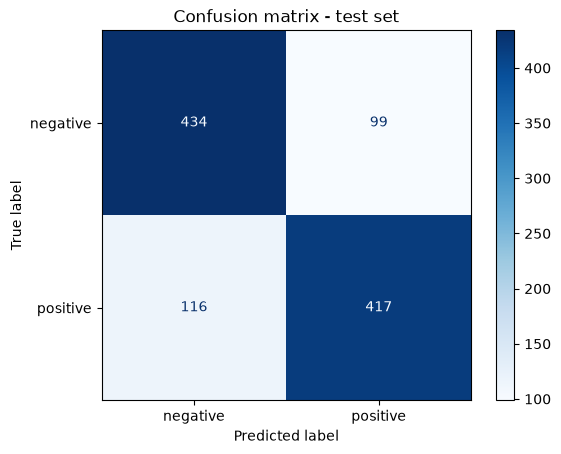

In [8]:
ConfusionMatrixDisplay.from_predictions(
    test_labels,
    test_predictions,
    display_labels=target_names,
    cmap="Blues",
)
plt.title("Confusion matrix - test set")
plt.show()


### Osservazioni

- La baseline ottiene accuracy `0.8218` e F1 macro `0.8217` sul validation set.
- Sul test set ottiene accuracy `0.7983` e F1 macro `0.7983`.
- Le due classi hanno prestazioni simili: sul test set il modello riconosce leggermente meglio la classe negativa in recall (`0.8143`) rispetto alla positiva (`0.7824`).


## 6. Sintesi finale

La baseline usa DistilBERT come feature extractor fisso e `LinearSVC` come classificatore. Il risultato finale sul test set e' circa `0.798` di accuracy e `0.798` di F1 macro.
